c:\Users\BosdurmazEB\AppData\Local\Programs\Python\Python311\Lib\site-packages\kfactory\decorators.py:406: UserWarning: `width` overrides `start_width`. Use only `start_width` going forward.
  cell = f(**params)  # type: ignore[call-arg]
d:\CleanroomFabrication\mesapdk-lab\spirals.py:43: UserWarning: {'width': 0.75} ignored for cross_section 'xs_ekn300_te_IMGREV'
  xs = gf.get_cross_section(cross_section, width = width)
c:\Users\BosdurmazEB\AppData\Local\Programs\Python\Python311\Lib\site-packages\gdsfactory\components\bends\bend_euler.py:110: UserWarning: {'width': 0.75} ignored for cross_section 'xs_ekn300_te_IMGREV'
  x = gf.get_cross_section(cross_section, width=width or x.width)


0.75
0.75
0.75
0.75
0.75
0.75
0.75
0.75
0.75
0.75


c:\Users\BosdurmazEB\AppData\Local\Programs\Python\Python311\Lib\site-packages\gdsfactory\components\waveguides\straight.py:33: UserWarning: {'width': 0.75} ignored for cross_section 'xs_ekn300_te_IMGREV'
  x = gf.get_cross_section(cross_section, width=width)
c:\Users\BosdurmazEB\AppData\Local\Programs\Python\Python311\Lib\site-packages\gdsfactory\components\bends\bend_euler.py:110: UserWarning: {'width': 2.5} ignored for cross_section 'xs_24911e99'
  x = gf.get_cross_section(cross_section, width=width or x.width)


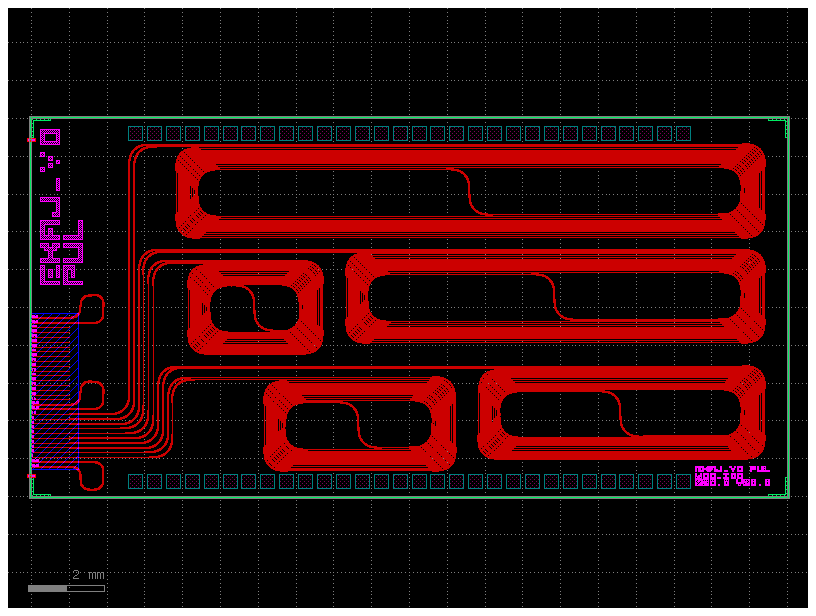

In [1]:
from EKST_v2_PUL import ekst_v2_pul_master

my_die = ekst_v2_pul_master()

my_die.plot()


WAFER_ID = "EKAJ_v1_W00"

24


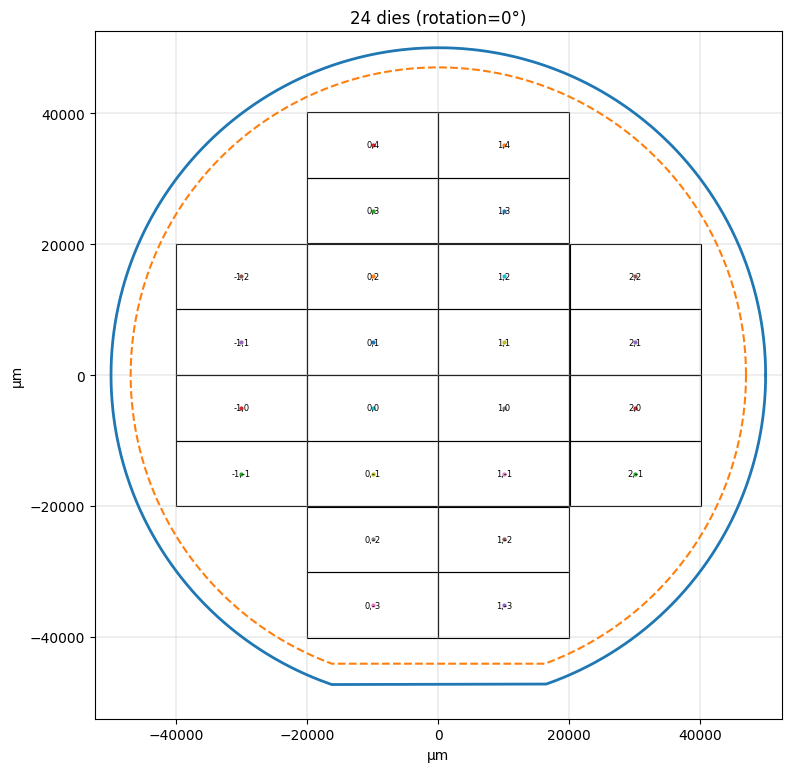

DiePackingResult(die_clean_size=(20000.0, 10000.0), die_step_size=(20045.0, 10045.0), wafer=WaferSpec(name='100mm', diameter_um=100000.0, edge_exclusion_um=3000, primary_flat_um=32500.0, secondary_flat_um=None, secondary_flat_angle_deg=None, notch_radius_um=None, notch_center_from_origin_um=None), usable_wafer=WaferSpec(name='100mm_usable', diameter_um=94000.0, edge_exclusion_um=0.0, primary_flat_um=32500.0, secondary_flat_um=None, secondary_flat_angle_deg=None, notch_radius_um=None, notch_center_from_origin_um=None), rotation=0, count=24, centers=[(-30067.5, -15067.5), (-30067.5, -5022.5), (-30067.5, 5022.5), (-30067.5, 15067.5), (-10022.5, -35157.5), (-10022.5, -25112.5), (-10022.5, -15067.5), (-10022.5, -5022.5), (-10022.5, 5022.5), (-10022.5, 15067.5), (-10022.5, 25112.5), (-10022.5, 35157.5), (10022.5, -35157.5), (10022.5, -25112.5), (10022.5, -15067.5), (10022.5, -5022.5), (10022.5, 5022.5), (10022.5, 15067.5), (10022.5, 25112.5), (10022.5, 35157.5), (30067.5, -15067.5), (30067.5

In [2]:
from helpers import wafer_spec 
from helpers.die_estimator import estimate_max_dies_on_wafer, plot_die_packing

wafer = wafer_spec.make_semi_wafer_spec("100mm", edge_exclusion_um=3000, use_secondary_flat=False)

result = estimate_max_dies_on_wafer(
    die=my_die,
    wafer=wafer,
    allow_rotation=True,
    offset_samples=11,
)

print(result.count)
plot_die_packing(result, show_centers=True, show_indices=True)
print(result)

In [3]:
from EKST_v2_BRT import ekst_v2_brt_master
from EKST_v2_PUL import ekst_v2_pul_master

from ekin_master_die import edge_coupler_array_ekn_def_butt, edge_coupler_array_ekn_def_butt_3loops, edge_coupler_array_ekn_def_centerskip

import gdsfactory as gf


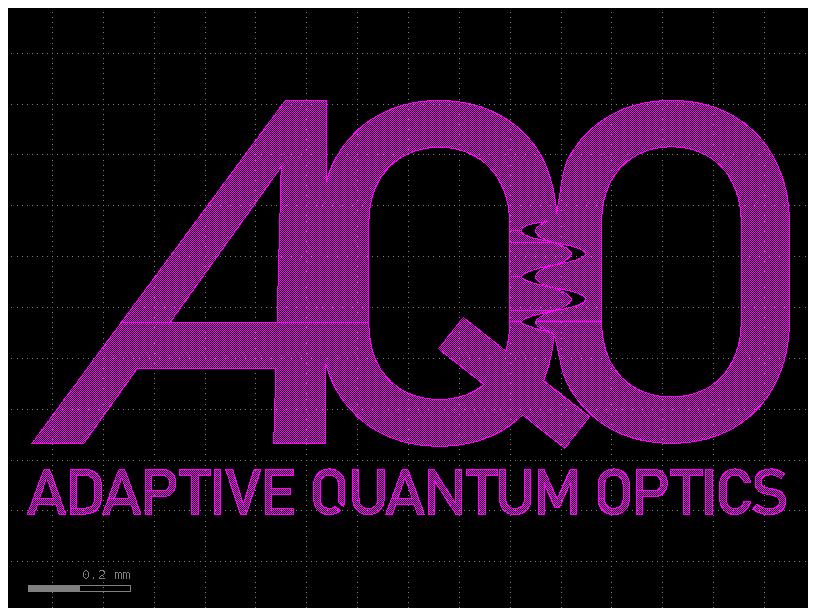

In [4]:
from logo_maker import svg_logo

logo = svg_logo(
        svg_path="./static/AQO_logo2.svg",
        layer=(5,0),
        target_width_um=1500.0,   # final width in um
        resolution=0.08,         # smaller -> smoother curves
        center=True,
    )

    # Preview in python / notebook
logo.plot()

In [5]:
BRT_TAP = gf.partial(ekst_v2_brt_master,ext_grp_spacing=127, label = "EKAJ_v0\nBRT TAP",logo=logo, logo_loc=(8500,-3750))
BRT_BUT = gf.partial(ekst_v2_brt_master,ext_grp_spacing=127, ec_array_def=edge_coupler_array_ekn_def_butt, label = "EKAJ_v0\nBRT BUT",logo=logo, logo_loc=(8500,-3750))

In [6]:
BRT_BUT().show()
# BRT_TAP().plot()

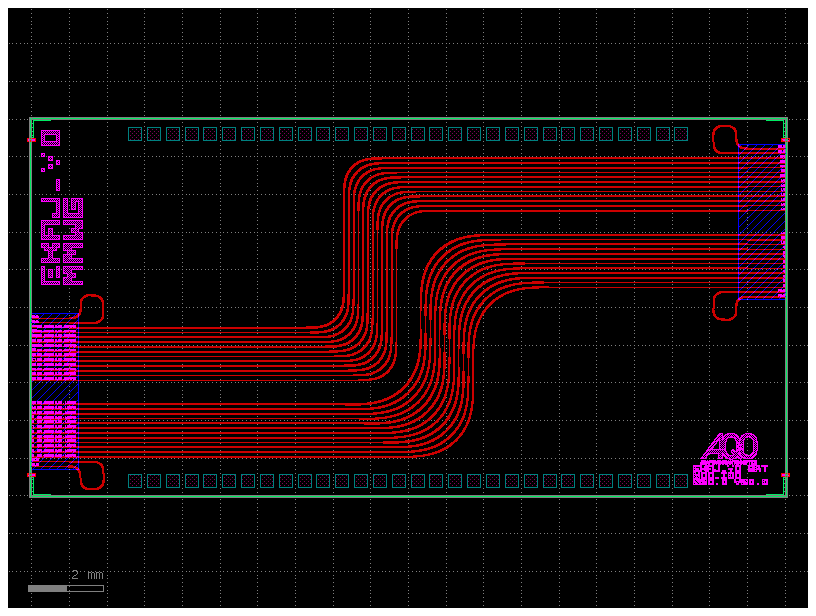

In [7]:
widths = (0.75, 1, 1.25, 1.5)

PUL_TAP_DEF=[]

for i in range(0, len(widths)):
    PUL_TAP_DEF.append(gf.partial(ekst_v2_pul_master, width = (widths[i],), label=f"EKAJ_v0\nPUL TAP\nW{widths[i]:.2f}",logo=logo, logo_loc=(-5000,-3000)))

PUL_BUT_DEF=[]

for i in range(0, len(widths)):
    PUL_BUT_DEF.append(gf.partial(ekst_v2_pul_master, width = (widths[i],),ec_array_def=edge_coupler_array_ekn_def_butt_3loops, label=f"EKAJ_v0\nPUL BUT\nW{widths[i]:.2f}",logo=logo, logo_loc=(-5000,-3000)))



# for pul in PUL_TAP_DEF:
#     pul().plot()

# for pul in PUL_BUT_DEF:
#     pul().plot()

MMWG_BUT = gf.partial(ekst_v2_brt_master, bend_rads=(2000,1000), widths=(2,4,6,8,2,4,6,8,2,4,6,8),ext_grp_spacing=512, label="EKAJ_v0\nMMWG", ec_array_def=edge_coupler_array_ekn_def_centerskip,logo=logo, logo_loc=(8500,-3750))

MMWG_BUT().plot()


In [8]:
from wafer_component import wafer_from_spec

c = wafer_from_spec(wafer=wafer)
c.show()

In [9]:
result.get_center((0,0))

(-10022.5, -5022.5)

In [10]:
assign_array = result.index_map.copy()
assign_array


{
    (0, -3): (-10022.5, -35157.5),
    (1, -3): (10022.5, -35157.5),
    (0, -2): (-10022.5, -25112.5),
    (1, -2): (10022.5, -25112.5),
    (-1, -1): (-30067.5, -15067.5),
    (0, -1): (-10022.5, -15067.5),
    (1, -1): (10022.5, -15067.5),
    (2, -1): (30067.5, -15067.5),
    (-1, 0): (-30067.5, -5022.5),
    (0, 0): (-10022.5, -5022.5),
    (1, 0): (10022.5, -5022.5),
    (2, 0): (30067.5, -5022.5),
    (-1, 1): (-30067.5, 5022.5),
    (0, 1): (-10022.5, 5022.5),
    (1, 1): (10022.5, 5022.5),
    (2, 1): (30067.5, 5022.5),
    (-1, 2): (-30067.5, 15067.5),
    (0, 2): (-10022.5, 15067.5),
    (1, 2): (10022.5, 15067.5),
    (2, 2): (30067.5, 15067.5),
    (0, 3): (-10022.5, 25112.5),
    (1, 3): (10022.5, 25112.5),
    (0, 4): (-10022.5, 35157.5),
    (1, 4): (10022.5, 35157.5)
}

In [11]:
for key in assign_array.keys():
    print("assign_array[{}] = MMWG_BUT".format(key))

assign_array[(0, -3)] = MMWG_BUT
assign_array[(1, -3)] = MMWG_BUT
assign_array[(0, -2)] = MMWG_BUT
assign_array[(1, -2)] = MMWG_BUT
assign_array[(-1, -1)] = MMWG_BUT
assign_array[(0, -1)] = MMWG_BUT
assign_array[(1, -1)] = MMWG_BUT
assign_array[(2, -1)] = MMWG_BUT
assign_array[(-1, 0)] = MMWG_BUT
assign_array[(0, 0)] = MMWG_BUT
assign_array[(1, 0)] = MMWG_BUT
assign_array[(2, 0)] = MMWG_BUT
assign_array[(-1, 1)] = MMWG_BUT
assign_array[(0, 1)] = MMWG_BUT
assign_array[(1, 1)] = MMWG_BUT
assign_array[(2, 1)] = MMWG_BUT
assign_array[(-1, 2)] = MMWG_BUT
assign_array[(0, 2)] = MMWG_BUT
assign_array[(1, 2)] = MMWG_BUT
assign_array[(2, 2)] = MMWG_BUT
assign_array[(0, 3)] = MMWG_BUT
assign_array[(1, 3)] = MMWG_BUT
assign_array[(0, 4)] = MMWG_BUT
assign_array[(1, 4)] = MMWG_BUT


In [12]:
assign_array[(0, -3)] = PUL_BUT_DEF[3]
assign_array[(1, -3)] = PUL_BUT_DEF[2]
assign_array[(0, -2)] = PUL_BUT_DEF[1]
assign_array[(1, -2)] = PUL_BUT_DEF[0]
assign_array[(-1, -1)] = PUL_TAP_DEF[0]
assign_array[(0, -1)] = MMWG_BUT
assign_array[(1, -1)] = MMWG_BUT
assign_array[(2, -1)] = PUL_TAP_DEF[3]
assign_array[(-1, 0)] = PUL_TAP_DEF[1]
assign_array[(0, 0)] = BRT_BUT
assign_array[(1, 0)] = BRT_TAP
assign_array[(2, 0)] = PUL_TAP_DEF[2]
assign_array[(-1, 1)] = PUL_TAP_DEF[2]
assign_array[(0, 1)] = BRT_TAP
assign_array[(1, 1)] = BRT_BUT
assign_array[(2, 1)] = PUL_TAP_DEF[1]
assign_array[(-1, 2)] = PUL_TAP_DEF[3]
assign_array[(0, 2)] = MMWG_BUT
assign_array[(1, 2)] = MMWG_BUT
assign_array[(2, 2)] = PUL_TAP_DEF[0]
assign_array[(0, 3)] = PUL_BUT_DEF[0]
assign_array[(1, 3)] = PUL_BUT_DEF[1]
assign_array[(0, 4)] = PUL_BUT_DEF[2]
assign_array[(1, 4)] = PUL_BUT_DEF[3]

In [13]:
assign_array


{
    (0, -3): functools.partial(<function ekst_v2_pul_master at 0x000001CF7F0AC180>, width=(1.5,), ec_array_def=functools.partial(<function edge_coupler_array at 0x000001CF7EDD8D60>, edge_coupler=functools.partial(<function butt_ec_with_anchor at 0x000001CF7EDD8AE0>, xs_waveguide=<function xs_ekn300_te_IMGREV at 0x000001CF7EB7BBA0>, cleave_marker_layer=(10, 0)), alignment_coupler=functools.partial(<function two_stage_inverse_taper_with_anchor at 0x000001CF7EDD8860>, xs_waveguide=<function xs_ekn300_te_IMGREV at 0x000001CF7EB7BBA0>, cleave_marker_layer=(10, 0), tip_width=0.3), n=32, n_alignment_loops=0, alignment_pairs={'0': 0, '1': 30, '3': 12}, adhesive_keepout_layer='TE', adhesive_keepout_margin=(250, 50), adhesive_keepout_axis='x', axis_reflection=False, widths=(0.75, 1, 1.25, 1.5), text=functools.partial(<function text_rectangular at 0x000001CF7ECC4E00>, layer='GE')), label='EKAJ_v0\nPUL BUT\nW1.50', logo=Component(name=svg_logo_SPp/static/AQO_logo2psvg_L5_0_TWU1500_THUNone__a35d

In [14]:
wafer_ID = "W00"

In [15]:
c.locked = False

die_name = ("{}_I{}_{}\nX{:.1f} Y{:.1f}".format(wafer_ID, 0, 0, float(result.get_center((0,0))[0])/1000, float(result.get_center((0,0))[1])/1000))
a = assign_array[(0,0)](chip_id_label = die_name)
a.show()

result.get_center((0,0))
wafer_ID = WAFER_ID.split("_")[-1]
for die in assign_array:
    if assign_array[die] !=None:
        die_name = ("{}_I{}_{}\nX{:.1f} Y{:.1f}".format(wafer_ID, die[0], die[1], float(result.get_center(die)[0])/1000, float(result.get_center(die)[1])/1000))
        dieref = c.add_ref(assign_array[die](chip_id_label = die_name,))
        dieref.dmove(origin=(0,0), destination=result.get_center(die))

d:\CleanroomFabrication\mesapdk-lab\spirals.py:43: UserWarning: {'width': 1.5} ignored for cross_section 'xs_8c5490b9'
  xs = gf.get_cross_section(cross_section, width = width)
c:\Users\BosdurmazEB\AppData\Local\Programs\Python\Python311\Lib\site-packages\gdsfactory\components\bends\bend_euler.py:110: UserWarning: {'width': 1.5} ignored for cross_section 'xs_8c5490b9'
  x = gf.get_cross_section(cross_section, width=width or x.width)


1.5
1.5
1.5
1.5
1.5
1.5
1.5
1.5
1.5
1.5


c:\Users\BosdurmazEB\AppData\Local\Programs\Python\Python311\Lib\site-packages\gdsfactory\components\waveguides\straight.py:33: UserWarning: {'width': 1.5} ignored for cross_section 'xs_8c5490b9'
  x = gf.get_cross_section(cross_section, width=width)
d:\CleanroomFabrication\mesapdk-lab\spirals.py:43: UserWarning: {'width': 1.25} ignored for cross_section 'xs_c94367c4'
  xs = gf.get_cross_section(cross_section, width = width)
c:\Users\BosdurmazEB\AppData\Local\Programs\Python\Python311\Lib\site-packages\gdsfactory\components\bends\bend_euler.py:110: UserWarning: {'width': 1.25} ignored for cross_section 'xs_c94367c4'
  x = gf.get_cross_section(cross_section, width=width or x.width)


1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25


c:\Users\BosdurmazEB\AppData\Local\Programs\Python\Python311\Lib\site-packages\gdsfactory\components\waveguides\straight.py:33: UserWarning: {'width': 1.25} ignored for cross_section 'xs_c94367c4'
  x = gf.get_cross_section(cross_section, width=width)
d:\CleanroomFabrication\mesapdk-lab\spirals.py:43: UserWarning: {'width': 1} ignored for cross_section 'xs_276501d0'
  xs = gf.get_cross_section(cross_section, width = width)
c:\Users\BosdurmazEB\AppData\Local\Programs\Python\Python311\Lib\site-packages\gdsfactory\components\bends\bend_euler.py:110: UserWarning: {'width': 1} ignored for cross_section 'xs_276501d0'
  x = gf.get_cross_section(cross_section, width=width or x.width)


1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0


c:\Users\BosdurmazEB\AppData\Local\Programs\Python\Python311\Lib\site-packages\gdsfactory\components\waveguides\straight.py:33: UserWarning: {'width': 1.0} ignored for cross_section 'xs_276501d0'
  x = gf.get_cross_section(cross_section, width=width)


In [16]:
from flexgrid import flexgrid

wlabel_text = gf.partial(gf.components.text, layer="GE")

wafer_label = wlabel_text(size=1000, text = WAFER_ID, justify = 'center' )
t_label = wlabel_text(size=750, text = 'Si3N4: {:.0f}nm'.format(321, justify = 'left' ))
teos_label = wlabel_text(size=750, text = ' TEOS: {:.0f}nm'.format(3000), justify = 'left' )

label_block = flexgrid(components=(
                                        #m_label,
                                        #asi_label,
                                        teos_label,
                                        t_label,
                                        wafer_label
    ),
                                    spacing=(100,200),
                                    shape=(5,1),
                                    align_x='xmin',
                                    align_y='center'
                                    )

lb_ref = c.add_ref(label_block, columns=2, rows=2, column_pitch=55000, row_pitch=-55000).dmove(origin=(0,0), destination=(-55000/2 - label_block.dxsize/2, 55000/2 - label_block.dysize/2))
lb_box_ref = c.add_ref(gf.components.rectangle(size=(label_block.dxsize, label_block.dysize), layer='FLOORPLAN'), columns=2, rows=2, column_pitch=55000 , row_pitch=55000).dmove(origin=(0,0), destination=(lb_ref.dxmin, lb_ref.dymin))


In [17]:
c.show()

In [18]:
#GET a list of cells, which suppose to be processed by PEC in a loop 

dies_to_PEC = []

for inst in c.insts:
    if "ekst_v2" in inst.cell_name:
        dies_to_PEC.append("True\t {}\n".format(inst.cell_name))
    else:
        dies_to_PEC.append("False\t {}\n".format(inst.cell_name))

dies_to_PEC


[
    'False\t Unnamed_714\n',
    'False\t Unnamed_723\n',
    'True\t ekst_v2_pul_master_EKST_v2_PUL_MDFdie_frame_mesa_Mdies__82104192\n',
    'True\t ekst_v2_pul_master_EKST_v2_PUL_MDFdie_frame_mesa_Mdies__40d6e798\n',
    'True\t ekst_v2_pul_master_EKST_v2_PUL_MDFdie_frame_mesa_Mdies__2e9d8b57\n',
    'True\t ekst_v2_pul_master_EKST_v2_PUL_MDFdie_frame_mesa_Mdies__9fe5f50b\n',
    'True\t ekst_v2_pul_master_EKST_v2_PUL_MDFdie_frame_mesa_Mdies__c1234747\n',
    'True\t ekst_v2_brt_master_EKST_v2_BRT_MDFdie_frame_mesa_Mdies__a6189206\n',
    'True\t ekst_v2_brt_master_EKST_v2_BRT_MDFdie_frame_mesa_Mdies__1d580795\n',
    'True\t ekst_v2_pul_master_EKST_v2_PUL_MDFdie_frame_mesa_Mdies__02bdb362\n',
    'True\t ekst_v2_pul_master_EKST_v2_PUL_MDFdie_frame_mesa_Mdies__2f83f215\n',
    'True\t ekst_v2_brt_master_EKST_v2_BRT_MDFdie_frame_mesa_Mdies__912d699e\n',
    'True\t ekst_v2_brt_master_EKST_v2_BRT_MDFdie_frame_mesa_Mdies__fc4a2bf9\n',
    'True\t ekst_v2_pul_master_EKST_v2_PUL_MDFdi

In [19]:
with open("exports/{}_cell_list.txt".format(WAFER_ID), "w") as output:
    output.write("enabled\t%VarName%\n")
    output.writelines(dies_to_PEC)

In [20]:
import kfactory as kf
from kfactory.utils.fill import fill_tiled

fc = gf.Component()
fc.add_ref(component=gf.components.rectangle(size=(20,20), layer=(71,0)))

#sp = get_tile_spacing(tile=TILE_SIZE, fill_density=PROC_STRUCTURE_DENSITY)
#fc.add_ref(component=gf.components.rectangle(size=(10,10), layer=DLAYER))

fill_tiled(
    c,
    fc,
    [(kf.kdb.LayerInfo(99, 0), 0)],
    exclude_layers=[
        (kf.kdb.LayerInfo(99, 500), 20),
        (kf.kdb.LayerInfo(1, 0), 20),
        (kf.kdb.LayerInfo(49, 0), 20),
        (kf.kdb.LayerInfo(3, 6), 20),
        (kf.kdb.LayerInfo(5, 0), 20),
        (kf.kdb.LayerInfo(41, 0), 20),
        (kf.kdb.LayerInfo(204, 0), 20)
        
    ],
    x_space=20,
    y_space=20,
    multi=True,
)



c.show()

In [21]:
c.cell_index()

711

In [22]:
c.write('exports/{}.oas'.format(WAFER_ID))
c.write_gds('exports/{}.gds'.format(WAFER_ID))

WindowsPath('exports/EKAJ_v1_W00.gds')